In [1]:
# Install timm for models and ptflops for efficiency metrics
!pip install -q timm ptflops gdown

In [2]:
import torch
import timm
import os
from ptflops import get_model_complexity_info

print(f"PyTorch version: {torch.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Model: {torch.cuda.get_device_name(0)}")

# Quick test of your first model selection
model = timm.create_model('resnet50', pretrained=True)
print("ResNet50 loaded successfully!")

# Directory to save your plots, tables, and model checkpoints
os.makedirs('/kaggle/working/results/plots', exist_ok=True)
os.makedirs('/kaggle/working/results/checkpoints', exist_ok=True)

PyTorch version: 2.9.0+cu126
GPU Available: True
GPU Model: Tesla T4


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

ResNet50 loaded successfully!


In [3]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# 1. Define standard transforms (ImageNet normalization is standard for timm models)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Load the full dataset (Assuming you downloaded/unzipped it to /kaggle/working/data/AID)
# Replace with your actual path
data_dir = '/kaggle/input/datasets/adarshguduru/gnr638-ass2/train_data' 
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)

# 3. Stratified Split (80% Train, 20% Val)
# Note: For the assignment, use a fixed seed for reproducibility!
seed = 42 
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], 
                                          generator=torch.Generator().manual_seed(seed))

# 4. DataLoaders (Optimized for 2 GPUs)
# Since you have 2 GPUs, you can double your batch size safely.
batch_size = 64 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

print(f"Classes: {len(full_dataset.classes)} | Total Images: {len(full_dataset)}")

Classes: 30 | Total Images: 6993


In [4]:
import torch
import timm
import os
import json
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader

# 1. SETUP GLOBAL VARIABLES
# Ensure these are defined before the training function is called
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = '/kaggle/working/results/scenario_4_2/'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Using device: {DEVICE}")

# 2. MODEL LOADER
def get_model(model_name, num_classes=30):
    model = timm.create_model(model_name, pretrained=True)
    if 'resnet' in model_name:
        model.fc = nn.Linear(model.fc.in_features, num_classes)
    elif 'efficientnet' in model_name:
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    elif 'convnext' in model_name:
        model.head.fc = nn.Linear(model.head.fc.in_features, num_classes)
    
    model = model.to(DEVICE)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)
    return model

# Load your big three
model_resnet = get_model('resnet50')
model_efficient = get_model('efficientnet_b0')
model_convnext = get_model('convnext_tiny')

print("Models prepared for 30-class classification on 2x T4 GPUs.")

Using device: cuda


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Models prepared for 30-class classification on 2x T4 GPUs.


In [5]:
from ptflops import get_model_complexity_info

# Helper to report metrics
def report_efficiency(model, name):
    # Use the .module if it's wrapped in DataParallel
    target_model = model.module if isinstance(model, nn.DataParallel) else model
    
    macs, params = get_model_complexity_info(target_model, (3, 224, 224), 
                                            as_strings=True, 
                                            print_per_layer_stat=False)
    print(f"[{name}] MACs: {macs} | Params: {params}")

report_efficiency(model_resnet, "ResNet50")
report_efficiency(model_efficient, "EfficientNet-B0")
report_efficiency(model_convnext, "ConvNeXt-Tiny")

[ResNet50] MACs: 4.13 GMac | Params: 23.57 M
[EfficientNet-B0] MACs: 390.87 MMac | Params: 4.05 M
[ConvNeXt-Tiny] MACs: 4.48 GMac | Params: 27.84 M


In [6]:
def setup_4_2_complete(model, strategy):
    target = model.module if isinstance(model, torch.nn.DataParallel) else model
    
    # 1. Freeze everything
    for param in target.parameters():
        param.requires_grad = False
    
    # 2. Apply 4.2 Strategies
    if strategy == 'linear_probe':
        # Everything stays frozen; only the head is unfrozen at the end
        pass
        
    elif strategy == 'last_block':
        # Reset and target ONLY the final stage
        if 'resnet' in str(type(target)).lower():
            # Layer4 is the final stage in ResNet
            for param in target.layer4.parameters(): 
                param.requires_grad = True
        elif 'efficientnet' in str(type(target)).lower():
            # EfficientNet uses 'blocks'; unfreeze ONLY the very last block sequence
            for param in target.blocks[-1].parameters(): 
                param.requires_grad = True
        elif 'convnext' in str(type(target)).lower():
            # ConvNeXt uses 'stages'; unfreeze the last one
            for param in target.stages[-1].parameters(): 
                param.requires_grad = True
            
    elif strategy == 'selective_20':
        # Reset: Freeze all
        for param in target.parameters():
            param.requires_grad = False
            
        all_params = list(target.named_parameters())
        total_param_count = sum(p.numel() for _, p in all_params)
        threshold = total_param_count * 0.20
        
        current_count = 0
        # Iterate backwards: start from the head and go into the backbone
        for name, param in reversed(all_params):
            if current_count < threshold:
                param.requires_grad = True
                current_count += param.numel()
            else:
                break
        
        # Double check: ensure the head is ALWAYS included
        for attr in ['fc', 'classifier', 'head']:
            if hasattr(target, attr):
                for p in getattr(target, attr).parameters():
                    p.requires_grad = True
        
    elif strategy == 'full':
        for param in target.parameters(): param.requires_grad = True

    # 3. Always unfreeze the classification head
    for attr in ['fc', 'classifier', 'head']:
        if hasattr(target, attr):
            head_layer = getattr(target, attr)
            for param in head_layer.parameters(): param.requires_grad = True
            
    return model

In [7]:
def audit_model_parameters(model, strategy_name):
    print(f"\n{'='*60}")
    print(f"AUDIT FOR STRATEGY: {strategy_name}")
    print(f"{'Layer Name':<45} | {'Status':<10} | {'Param Count':<12}")
    print("-" * 60)
    
    target = model.module if isinstance(model, torch.nn.DataParallel) else model
    
    total_params = 0
    trainable_params = 0
    
    for name, param in target.named_parameters():
        p_count = param.numel()
        total_params += p_count
        status = "TRAINABLE" if param.requires_grad else "FROZEN"
        if param.requires_grad:
            trainable_params += p_count
            
        # We only print a subset to avoid flooding the console
        # Print if it's trainable OR if it's the start of a major block
        if param.requires_grad or any(x in name for x in ['layer1.0.conv1', 'layer2.0.conv1', 'layer3.0.conv1', 'layer4.0.conv1']):
            print(f"{name[:44]:<45} | {status:<10} | {p_count:,}")

    print("-" * 60)
    print(f"TOTAL PARAMETERS:     {total_params:,}")
    print(f"TRAINABLE PARAMETERS: {trainable_params:,}")
    print(f"PERCENTAGE UNFROZEN:  {(trainable_params/total_params)*100:.2f}%")
    print(f"{'='*60}\n")

# --- HOW TO USE ---
# 1. Setup your model with the strategy
model = setup_4_2_complete(model_convnext, 'linear_probe')
# 2. Run the audit
audit_model_parameters(model, 'ResNet50_linear_probe')


AUDIT FOR STRATEGY: ResNet50_linear_probe
Layer Name                                    | Status     | Param Count 
------------------------------------------------------------
head.norm.weight                              | TRAINABLE  | 768
head.norm.bias                                | TRAINABLE  | 768
head.fc.weight                                | TRAINABLE  | 23,040
head.fc.bias                                  | TRAINABLE  | 30
------------------------------------------------------------
TOTAL PARAMETERS:     27,843,198
TRAINABLE PARAMETERS: 24,606
PERCENTAGE UNFROZEN:  0.09%



In [8]:
def train_4_2_full_stats(model, train_loader, val_loader, criterion, optimizer, run_name, epochs=8):
    history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': [], 'grad_norms': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        epoch_norms = []
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            
            # REQUIREMENT: Gradient norm statistics across layers
            total_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    total_norm += p.grad.data.norm(2).item() ** 2
            epoch_norms.append(total_norm ** 0.5)
            
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
        
        # Validation
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                v_loss += criterion(outputs, labels).item() * images.size(0)
                _, predicted = outputs.max(1)
                v_total += labels.size(0)
                v_correct += predicted.eq(labels).sum().item()

        history['train_acc'].append(100. * correct / total)
        history['val_acc'].append(100. * v_correct / v_total)
        history['train_loss'].append(running_loss / total)
        history['val_loss'].append(v_loss / v_total)
        history['grad_norms'].append(np.mean(epoch_norms))
        
        print(f"Epoch {epoch+1} | {run_name} | Val Acc: {history['val_acc'][-1]:.1f}% | Grad Norm: {history['grad_norms'][-1]:.4f}")
        
    with open(f"{RESULTS_DIR}{run_name}_history.json", 'w') as f:
        json.dump(history, f)
    return history

In [9]:
backbones = {
    'resnet50': 'ResNet50',
    'efficientnet_b0': 'EffNetB0',
    'convnext_tiny': 'ConvNeXt'
}
strategies = ['linear_probe', 'last_block', 'selective_20', 'full']


# Epoch configuration per model
epoch_config = {
    'resnet50': 20,
    'efficientnet_b0': 20,
    'convnext_tiny': 10
}

for model_key, model_label in backbones.items():
    # Get the specific epoch count for this model
    num_epochs = epoch_config.get(model_key, 10)
    for strat in strategies:
        print(f"\n>>> 4.2 EXPERIMENT: {model_label} | STRATEGY: {strat}")
        
        model = get_model(model_key) # num_classes should match your data
        model = setup_4_2_complete(model, strat)
        
        # Report Unfrozen Percentage
        total_p = sum(p.numel() for p in model.parameters())
        trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Unfrozen: {(trainable_p/total_p)*100:.2f}% parameters")
        
        optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5)
        criterion = nn.CrossEntropyLoss()
        
        train_4_2_full_stats(model, train_loader, val_loader, criterion, optimizer, 
                            run_name=f"{model_label}_{strat}", epochs=num_epochs)

        # Define the path for the model checkpoint
        checkpoint_path = f"{RESULTS_DIR}{model_label}_{strat}_best.pth"
        
        # Save the model state dictionary
        # We save the .module if using DataParallel, otherwise the model itself
        state_to_save = model.module.state_dict() if isinstance(model, torch.nn.DataParallel) else model.state_dict()
        torch.save(state_to_save, checkpoint_path)
        
        print(f"Model saved to: {checkpoint_path}")
        
        # Cleanup
        del model, optimizer
        torch.cuda.empty_cache()

print("\n--- Scenario 4.2 Complete ---")


>>> 4.2 EXPERIMENT: ResNet50 | STRATEGY: linear_probe
Unfrozen: 0.26% parameters
Epoch 1 | ResNet50_linear_probe | Val Acc: 5.1% | Grad Norm: 0.8459
Epoch 2 | ResNet50_linear_probe | Val Acc: 8.6% | Grad Norm: 0.8435
Epoch 3 | ResNet50_linear_probe | Val Acc: 12.0% | Grad Norm: 0.8353
Epoch 4 | ResNet50_linear_probe | Val Acc: 13.1% | Grad Norm: 0.8346
Epoch 5 | ResNet50_linear_probe | Val Acc: 15.3% | Grad Norm: 0.8286
Epoch 6 | ResNet50_linear_probe | Val Acc: 17.4% | Grad Norm: 0.8234
Epoch 7 | ResNet50_linear_probe | Val Acc: 19.9% | Grad Norm: 0.8226
Epoch 8 | ResNet50_linear_probe | Val Acc: 22.2% | Grad Norm: 0.8211
Epoch 9 | ResNet50_linear_probe | Val Acc: 24.7% | Grad Norm: 0.8246
Epoch 10 | ResNet50_linear_probe | Val Acc: 25.1% | Grad Norm: 0.8239
Epoch 11 | ResNet50_linear_probe | Val Acc: 29.8% | Grad Norm: 0.8172
Epoch 12 | ResNet50_linear_probe | Val Acc: 29.2% | Grad Norm: 0.8303
Epoch 13 | ResNet50_linear_probe | Val Acc: 33.0% | Grad Norm: 0.8237
Epoch 14 | ResNet50

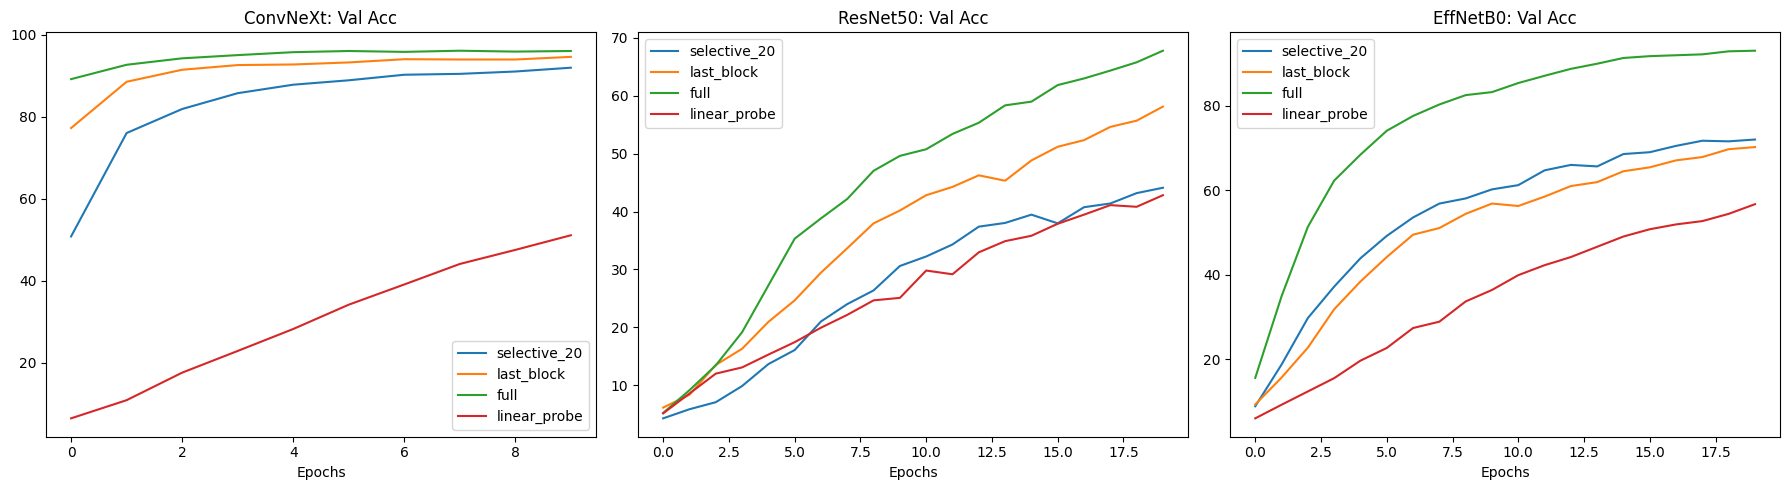

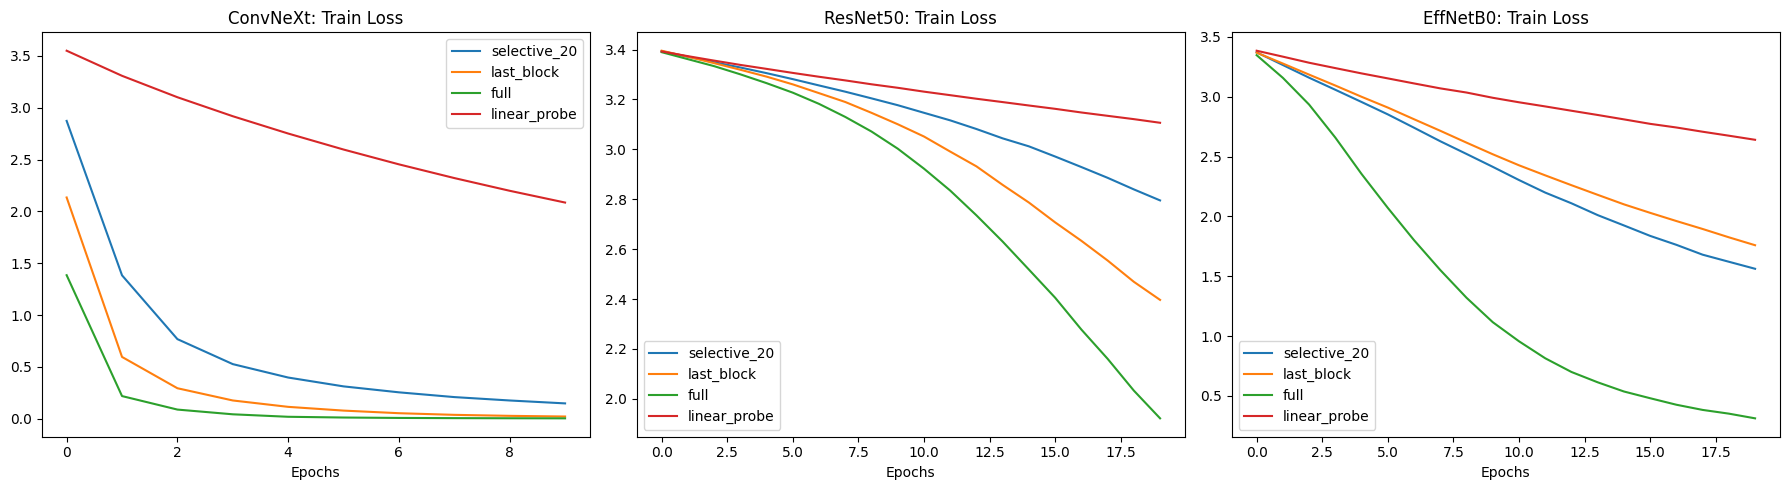

In [10]:
import matplotlib.pyplot as plt
import glob
import os
import json
import numpy as np

def plot_4_2_results(results_dir):
    history_files = glob.glob(f"{results_dir}/*.json")
    data_map = {}
    
    for f in history_files:
        # Get filename without extension
        name = os.path.basename(f).replace('_history.json', '')
        
        # Identify which model and strategy this file belongs to
        model_name = None
        for m in ['ResNet50', 'EffNetB0', 'ConvNeXt']:
            if name.startswith(m):
                model_name = m
                strategy = name.replace(f"{m}_", "")
                break
        
        if model_name:
            if model_name not in data_map: 
                data_map[model_name] = {}
            with open(f, 'r') as j:
                data_map[model_name][strategy] = json.load(j)

    # --- PLOT 1: Validation Accuracy ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, model in enumerate(data_map.keys()):
        for strategy, history in data_map[model].items():
            axes[i].plot(history['val_acc'], label=strategy)
        axes[i].set_title(f"{model}: Val Acc")
        axes[i].set_xlabel("Epochs")
        axes[i].legend()
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: Training Loss (Stability) ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, model in enumerate(data_map.keys()):
        for strategy, history in data_map[model].items():
            axes[i].plot(history['train_loss'], label=strategy)
        axes[i].set_title(f"{model}: Train Loss")
        axes[i].set_xlabel("Epochs")
        axes[i].legend()
    plt.tight_layout()
    plt.show()
    
    return data_map  # <--- THIS IS THE FIX

# Now run it and catch the returned data
data_map = plot_4_2_results("/kaggle/working/results/scenario_4_2")

In [11]:
print(f"| Model | Strategy | Final Val Acc | Avg Grad Norm |")
print(f"| :--- | :--- | :--- | :--- |")

for model in data_map.keys():
    for strategy, history in data_map[model].items():
        final_acc = max(history['val_acc'])
        avg_norm = np.mean(history['grad_norms'])
        print(f"| {model} | {strategy} | {final_acc:.2f}% | {avg_norm:.4f} |")

| Model | Strategy | Final Val Acc | Avg Grad Norm |
| :--- | :--- | :--- | :--- |
| ConvNeXt | selective_20 | 91.99% | 5.5209 |
| ConvNeXt | last_block | 94.64% | 5.6250 |
| ConvNeXt | full | 96.14% | 11.6421 |
| ConvNeXt | linear_probe | 51.11% | 5.7703 |
| ResNet50 | selective_20 | 44.10% | 0.9196 |
| ResNet50 | last_block | 58.11% | 1.0210 |
| ResNet50 | full | 67.76% | 1.9658 |
| ResNet50 | linear_probe | 42.82% | 0.8242 |
| EffNetB0 | selective_20 | 71.98% | 1.8269 |
| EffNetB0 | last_block | 70.19% | 1.8930 |
| EffNetB0 | full | 92.99% | 2.2308 |
| EffNetB0 | linear_probe | 56.68% | 1.7565 |
